# Blind 번아웃 게시글 분석

> **파이프라인**  
> `blind_raw.csv 로드` → `전처리` → **분석 단위 선택** → `형태소 분석(Kiwi)`  
> → **방법 1** TF-IDF + KMeans  
> → **방법 2** Doc2Vec + KMeans  
> → **방법 3** SBERT + KMeans  
> → 군집별 키워드 & 대표문장 해석 → 결과 저장

---
### 📌 분석 단위 2가지 모드
| 모드 | `ANALYSIS_MODE` | 분석 단위 | 특징 |
|------|----------------|-----------|------|
| 문장 분리 | `"sentence"` | 게시글을 문장 단위로 쪼개서 분석 | 세밀한 토픽 발견에 유리 |
| 문서 전체 | `"document"` | 게시글 본문(clean_body) 통째로 분석 | 게시글 전체 맥락 보존에 유리 |

> **STEP 2의 `ANALYSIS_MODE` 변수 하나만 바꾸면** 이후 모든 셀이 자동으로 대응합니다.

## STEP 0. 패키지 설치

In [1]:
# 처음 실행 시 주석 해제
!pip install kiwipiepy umap-learn scikit-learn gensim matplotlib pandas tqdm
!pip install sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 14.5 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=aab9c85feebaca0e25c253bfb75606a629deaccf3de2354232e45ac0718b23cc
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model


## STEP 1. 데이터 로드 & 전처리

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import re
from tqdm import tqdm

RAW_CSV = "/content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX프로젝트/marged_output/01_Entrance_merged.csv"   # 크롤링 결과 파일명 (필요 시 수정)


raw_df = pd.read_csv((RAW_CSV), encoding="utf-8-sig")
raw_df = raw_df.dropna(subset=["text"]).reset_index(drop=True)
print(f"게시글 수: {len(raw_df)}건")
raw_df.head(3)

게시글 수: 65338건


,url,date,title,content,text,source_file
0,https://cafe.naver.com/overseer/1591944?art=ZX...,2026.03.12. 14:19,자유수다방현관시트지색,오늘 타일을 보고왔는데 눈이 핑핑돌더라구요ㅋㅋ 계속보니 이색이 이색이고 저색이 저색...,자유수다방현관시트지색 오늘 타일을 보고왔는데 눈이 핑핑돌더라구요ㅋㅋ 계속보니 이색이...,네이버카페_현관_crawling
1,https://cafe.naver.com/overseer/1592626?art=ZX...,2026.03.13. 07:11,인테리어 질문현관 디딤석 없는집?,안녕하세여 현관 인테리어 예정입니다 현관 디딤석이 없는 시공사진을 찾고있는데 아무리...,인테리어 질문현관 디딤석 없는집? 안녕하세여 현관 인테리어 예정입니다 현관 디딤석이...,네이버카페_현관_crawling
2,https://cafe.naver.com/0404ab/4089048?art=ZXh0...,2026.03.13. 15:37,기타업종 구직/홍보 게시판망원2동 누수탐지 주택 현관 천장 누수,​ 망원2동 누수탐지 주택 현관 천장 누수 ​ 주택 현관 천장에서 물이 떨어지는 모...,기타업종 구직/홍보 게시판망원2동 누수탐지 주택 현관 천장 누수 ​ 망원2동 누수탐...,네이버카페_현관_crawling


In [4]:
def clean_text(text):
    """URL 제거, 특수문자 제거, 공백 정규화"""
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9가-힣\s\n.,!?]", "", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()

raw_df["clean_body"] = raw_df["text"].apply(clean_text)
print("전처리 완료 ✅")
raw_df[[ "clean_body"]].head(3)

전처리 완료 ✅


,clean_body
0,자유수다방현관시트지색 오늘 타일을 보고왔는데 눈이 핑핑돌더라구요 계속보니 이색이 이...
1,인테리어 질문현관 디딤석 없는집? 안녕하세여 현관 인테리어 예정입니다 현관 디딤석이...
2,기타업종 구직홍보 게시판망원2동 누수탐지 주택 현관 천장 누수 망원2동 누수탐지 주...


## STEP 2. 분석 단위 선택 ⬅️ 여기서 모드를 선택하세요

```
ANALYSIS_MODE = "sentence"   # 문장 분리 모드
ANALYSIS_MODE = "document"   # 문서 전체 모드
```

In [5]:
# ─── 모드 선택 ───────────────────────────────────────────────
ANALYSIS_MODE = "document"   # "sentence" | "document"
# ─────────────────────────────────────────────────────────────

def is_noise(s):
    s = s.strip()
    if re.search(r'https?://', s): return True
    if re.fullmatch(r'[\u2500\-\s]+', s): return True
    BOILERPLATE = ["MBTI 검사", "이 서비스는", "신고하기", "공유하기"]
    return any(p in s for p in BOILERPLATE)

def split_sentences(text):
    """\\n 및 .!? 기준 문장 분리, 10자 미만 제거"""
    lines = text.split("\n")
    sentences = []
    for line in lines:
        parts = re.split(r'(?<=[.!?])\s+', line.strip())
        sentences.extend(parts)
    return [s.strip() for s in sentences if len(s.strip()) >= 10]


if ANALYSIS_MODE == "sentence":
    # ── 문장 분리 모드 ──────────────────────────────────────────
    records = []
    for doc_idx, row in raw_df.iterrows():
        for sent in split_sentences(str(row["clean_body"])):
            if not is_noise(sent):
                records.append({
                    "doc_idx" : doc_idx,
                    "url"     : row["url"],
                    "title"   : row["제목"],
                    "text"    : sent       # 공통 컬럼명: text
                })
    analysis_df = pd.DataFrame(records).reset_index(drop=True)
    TEXT_COL = "text"
    print(f"[sentence 모드] 게시글 {len(raw_df)}건 → 문장 {len(analysis_df)}개 ✅")

else:
    # ── 문서 전체 모드 ─────────────────────────────────────────
    analysis_df = raw_df[[ "clean_body"]].copy()
    analysis_df = analysis_df.rename(columns={"clean_body": "text"})
    analysis_df.insert(0, "doc_idx", analysis_df.index)
    analysis_df = analysis_df[~analysis_df["text"].apply(is_noise)].reset_index(drop=True)
    TEXT_COL = "text"
    print(f"[document 모드] 게시글 {len(analysis_df)}건 ✅")

print(f"\n분석 단위: {'문장' if ANALYSIS_MODE == 'sentence' else '게시글 전체'}")
analysis_df.head()

[document 모드] 게시글 65308건 ✅

분석 단위: 게시글 전체


,doc_idx,text
0,0,자유수다방현관시트지색 오늘 타일을 보고왔는데 눈이 핑핑돌더라구요 계속보니 이색이 이...
1,1,인테리어 질문현관 디딤석 없는집? 안녕하세여 현관 인테리어 예정입니다 현관 디딤석이...
2,2,기타업종 구직홍보 게시판망원2동 누수탐지 주택 현관 천장 누수 망원2동 누수탐지 주...
3,3,자유수다방현관쪽에 전신거울 신발장쪽 현관쪽에 벽걸이 전신거울 하려고 하는데 택배왔는...
4,4,"인테리어 질문현관 덧방, 디딤석 철거 고민됩니다 ! 23년 내 매도 예정이나, 아파..."


In [6]:
import pandas as pd

STOPWORDS_CSV = "/content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX프로젝트/ko-stopwords.csv"   # 파일 경로 필요 시 수정

sw_df = pd.read_csv(STOPWORDS_CSV, encoding="utf-8-sig")
base_stopwords = set(sw_df["stopwords"].dropna().str.strip().tolist())

print(f"기본 불용어 수: {len(base_stopwords)}개")
print(f"샘플: {list(base_stopwords)[:15]}")

기본 불용어 수: 599개
샘플: ['갖고말하자면', '할 힘이 있다', '흥', '이때', '다만', '응당', '나머지는', '마저', '이렇게되면', '어느것', '댕그', '따지지 않다', '제', '구토하다', '어느쪽']


In [7]:
# ── 군집 키워드 결과에서 확인된 무의미 단어 ───────────────────
CUSTOM_STOPWORDS = {
    # 일반 부사 / 강조어
    "너무", "그냥", "진짜", "정말",
    "약간", "되게", "꽤", "제일", "가장", "더",
    "더욱", "잘", "못", "안", "다",

    # 지시어 / 대명사 계열
    "내가", "나는", "나도", "제가", "저는", "저도",
    "이게", "그게", "저게", "이거", "그거", "저거",
    "이런", "그런", "저런", "이렇게", "그렇게",
    "여기", "거기", "저기",

    # 동사/형용사 활용형 (Kiwi가 원형으로 못 잡는 경우)
    "하고", "하는", "하면", "하기", "해서", "했는데",
    "있는", "있고", "없는", "없고",
    "같고", "같은", "같이",
    "아무것도",

    # 수량/정도
    "한번", "이번", "그때", "대한", "대하"
}

# ── 합치기 ────────────────────────────────────────────────────
ALL_STOPWORDS = base_stopwords | CUSTOM_STOPWORDS

print(f"기본 불용어  : {len(base_stopwords)}개")
print(f"커스텀 추가  : {len(CUSTOM_STOPWORDS)}개")
print(f"최종 불용어  : {len(ALL_STOPWORDS)}개")

기본 불용어  : 599개
커스텀 추가  : 54개
최종 불용어  : 646개


In [8]:
from kiwipiepy import Kiwi
from tqdm import tqdm

kiwi = Kiwi()

def tokenize(text: str) -> list:
    """
    Kiwi 형태소 분석 + 불용어 제거
    - 추출 품사: NNG(일반명사), NNP(고유명사), VV(동사), VA(형용사)
    - 2글자 이상, ALL_STOPWORDS 제외
    """
    return [
        token.form
        for token in kiwi.tokenize(text)
        if token.tag in ("NNG", "NNP", "VV", "VA")
        and len(token.form) > 1
        and token.form not in ALL_STOPWORDS
    ]

# ── 적용 ─────────────────────────────────────────────────────
tqdm.pandas(desc="형태소 분석 + 불용어 제거")
analysis_df["tokens"]     = analysis_df[TEXT_COL].progress_apply(tokenize)
analysis_df["tokens_str"] = analysis_df["tokens"].apply(lambda x: " ".join(x))

# 토큰 없는 행 제거
before = len(analysis_df)
analysis_df = analysis_df[analysis_df["tokens"].map(len) > 0].reset_index(drop=True)
print(f"완료: {before}건 → {len(analysis_df)}건 (토큰 없는 행 {before - len(analysis_df)}건 제거) ✅")
analysis_df[["text", "tokens"]].head()

형태소 분석 + 불용어 제거: 100%|██████████| 65308/65308 [15:08<00:00, 71.92it/s]  


완료: 65308건 → 65299건 (토큰 없는 행 9건 제거) ✅


,text,tokens
0,자유수다방현관시트지색 오늘 타일을 보고왔는데 눈이 핑핑돌더라구요 계속보니 이색이 이...,"[자유, 다방, 현관, 시트지, 타일, 이색, 생각, 생각, 민트, 타일, 들어오,..."
1,인테리어 질문현관 디딤석 없는집? 안녕하세여 현관 인테리어 예정입니다 현관 디딤석이...,"[인테리어, 질문, 현관, 디디, 안녕, 현관, 인테리어, 예정, 현관, 디디, 시..."
2,기타업종 구직홍보 게시판망원2동 누수탐지 주택 현관 천장 누수 망원2동 누수탐지 주...,"[업종, 구직, 홍보, 게시판, 망원, 누수, 탐지, 주택, 현관, 천장, 누수, ..."
3,자유수다방현관쪽에 전신거울 신발장쪽 현관쪽에 벽걸이 전신거울 하려고 하는데 택배왔는...,"[자유, 다방, 현관, 전신, 거울, 신발장, 현관, 벽걸이, 전신, 거울, 택배,..."
4,"인테리어 질문현관 덧방, 디딤석 철거 고민됩니다 ! 23년 내 매도 예정이나, 아파...","[인테리어, 질문, 현관, 디디, 철거, 고민, 매도, 예정, 아파트, 순정, 상태..."


In [10]:
from collections import Counter

all_tokens = [t for tokens in analysis_df["tokens"] for t in tokens]
top30 = Counter(all_tokens).most_common(30)

print("불용어 제거 후 상위 30개 토큰:")
print("-" * 40)
for word, cnt in top30:
    print(f"  {word:12s}  {cnt:5d}회")

불용어 제거 후 상위 30개 토큰:
----------------------------------------
  현관            134751회
  인테리어          110733회
  청소            72199회
  시공            71076회
  공간            67702회
  아파트           55042회
  신발장           50060회
  주방            46908회
  타일            42530회
  정리            42468회
  거실            41796회
  사용            34151회
  설치            31771회
  보이            31107회
  욕실            31009회
  조명            30687회
  수납            28063회
  바닥            27410회
  중문            26452회
  입주            26123회
  업체            25981회
  디자인           24624회
  가능            24517회
  전체            24237회
  도어            24165회
  공사            24107회
  화이트           23894회
  사진            23547회
  안방            23542회
  재생            23205회


## STEP 3. 형태소 분석 (Kiwi)

In [11]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

def tokenize(text: str) -> list:
    """Kiwi — 일반명사(NNG), 고유명사(NNP), 동사(VV), 형용사(VA), 2글자 이상"""
    return [
        token.form
        for token in kiwi.tokenize(text)
        if token.tag in ("NNG", "NNP", "VV", "VA") and len(token.form) > 1
    ]

tqdm.pandas(desc=f"형태소 분석 [{ANALYSIS_MODE} 모드]")
analysis_df["tokens"]     = analysis_df[TEXT_COL].progress_apply(tokenize)
analysis_df["tokens_str"] = analysis_df["tokens"].apply(lambda x: " ".join(x))

# 토큰 없는 행 제거
analysis_df = analysis_df[analysis_df["tokens"].map(len) > 0].reset_index(drop=True)
print(f"형태소 분석 완료: {len(analysis_df)}건 ✅")
analysis_df[[TEXT_COL, "tokens"]].head()

형태소 분석 [document 모드]: 100%|██████████| 65299/65299 [14:34<00:00, 74.64it/s]  


형태소 분석 완료: 65299건 ✅


,text,tokens
0,자유수다방현관시트지색 오늘 타일을 보고왔는데 눈이 핑핑돌더라구요 계속보니 이색이 이...,"[자유, 다방, 현관, 시트지, 타일, 이색, 생각, 생각, 민트, 타일, 들어오,..."
1,인테리어 질문현관 디딤석 없는집? 안녕하세여 현관 인테리어 예정입니다 현관 디딤석이...,"[인테리어, 질문, 현관, 디디, 안녕, 현관, 인테리어, 예정, 현관, 디디, 시..."
2,기타업종 구직홍보 게시판망원2동 누수탐지 주택 현관 천장 누수 망원2동 누수탐지 주...,"[기타, 업종, 구직, 홍보, 게시판, 망원, 누수, 탐지, 주택, 현관, 천장, ..."
3,자유수다방현관쪽에 전신거울 신발장쪽 현관쪽에 벽걸이 전신거울 하려고 하는데 택배왔는...,"[자유, 다방, 현관, 전신, 거울, 신발장, 현관, 벽걸이, 전신, 거울, 택배,..."
4,"인테리어 질문현관 덧방, 디딤석 철거 고민됩니다 ! 23년 내 매도 예정이나, 아파...","[인테리어, 질문, 현관, 디디, 철거, 고민, 매도, 예정, 아파트, 순정, 상태..."


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
import umap
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family="Malgun Gothic")   # Mac: AppleGothic
plt.rcParams["axes.unicode_minus"] = False

---
## 방법 3. SBERT + KMeans 군집화

> `jhgan/ko-sroberta-multitask` — 한국어 특화 SBERT 모델.  
> 형태소 분석 없이 원문을 768차원 벡터로 변환하므로 감성·문맥 정보가 가장 잘 보존됩니다.  
> **document 모드**일 때는 긴 텍스트를 512 토큰으로 잘라 임베딩하니 참고하세요.

### 3-1. SBERT 임베딩

In [13]:
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer("jhgan/ko-sroberta-multitask")
texts = analysis_df[TEXT_COL].tolist()

embeddings = sbert.encode(
    texts,
    batch_size = 32 if ANALYSIS_MODE == "document" else 64,
    show_progress_bar  = True,
    normalize_embeddings = True
)
print(f"임베딩 shape: {embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2041 [00:00<?, ?it/s]

임베딩 shape: (65299, 768)


### 3-2. UMAP 10D 축소 후 최적 K 탐색

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
SBERT K 탐색: 100%|██████████| 12/12 [13:10<00:00, 65.87s/it]


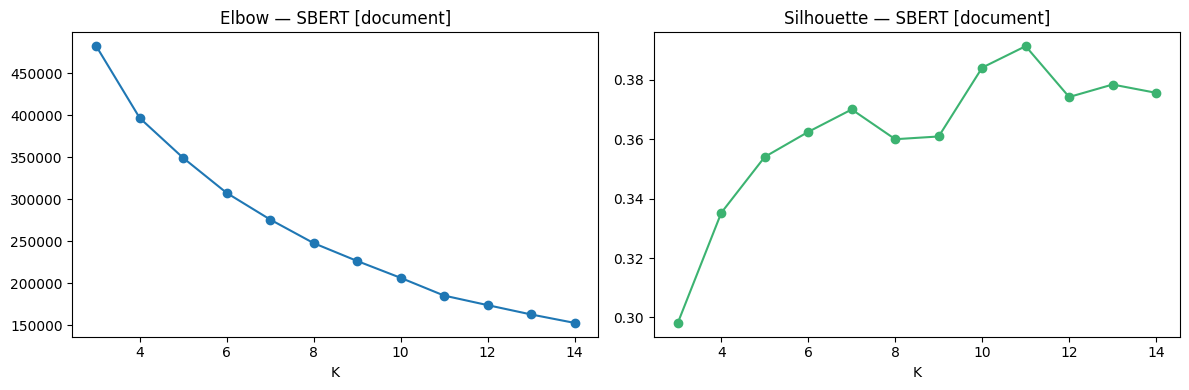

Silhouette 기준 최적 K = 11


In [14]:
reducer_10d = umap.UMAP(n_components=10, metric="cosine", random_state=42)
reduced_10d = reducer_10d.fit_transform(embeddings)

K_RANGE = range(3, 15)
inertias_s, silhouettes_s = [], []

for k in tqdm(K_RANGE, desc="SBERT K 탐색"):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(reduced_10d)
    inertias_s.append(km.inertia_)
    silhouettes_s.append(silhouette_score(reduced_10d, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias_s, marker="o")
axes[0].set_title(f"Elbow — SBERT [{ANALYSIS_MODE}]"); axes[0].set_xlabel("K")
axes[1].plot(list(K_RANGE), silhouettes_s, marker="o", color="mediumseagreen")
axes[1].set_title(f"Silhouette — SBERT [{ANALYSIS_MODE}]"); axes[1].set_xlabel("K")
plt.tight_layout(); plt.savefig(f"sbert_optimal_k_{ANALYSIS_MODE}.png", dpi=150); plt.show()

best_k_sbert = list(K_RANGE)[silhouettes_s.index(max(silhouettes_s))]
print(f"Silhouette 기준 최적 K = {best_k_sbert}")

### 3-3. KMeans 군집화 & UMAP 2D 시각화

군집별 게시글 수 (SBERT):
cluster_sbert
0    13964
1     9536
2    16562
3     4226
4    21011
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/tmp/ipykernel_2286/2531957070.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_s = plt.cm.get_cmap("tab10", N_SBERT)
/tmp/ipykernel_2286/2531957070.py:19: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig(f"sbert_cluster_2d_{ANALYSIS_MODE}.png", dpi=150); plt.show()
/tmp/ipykernel_2286/2531957

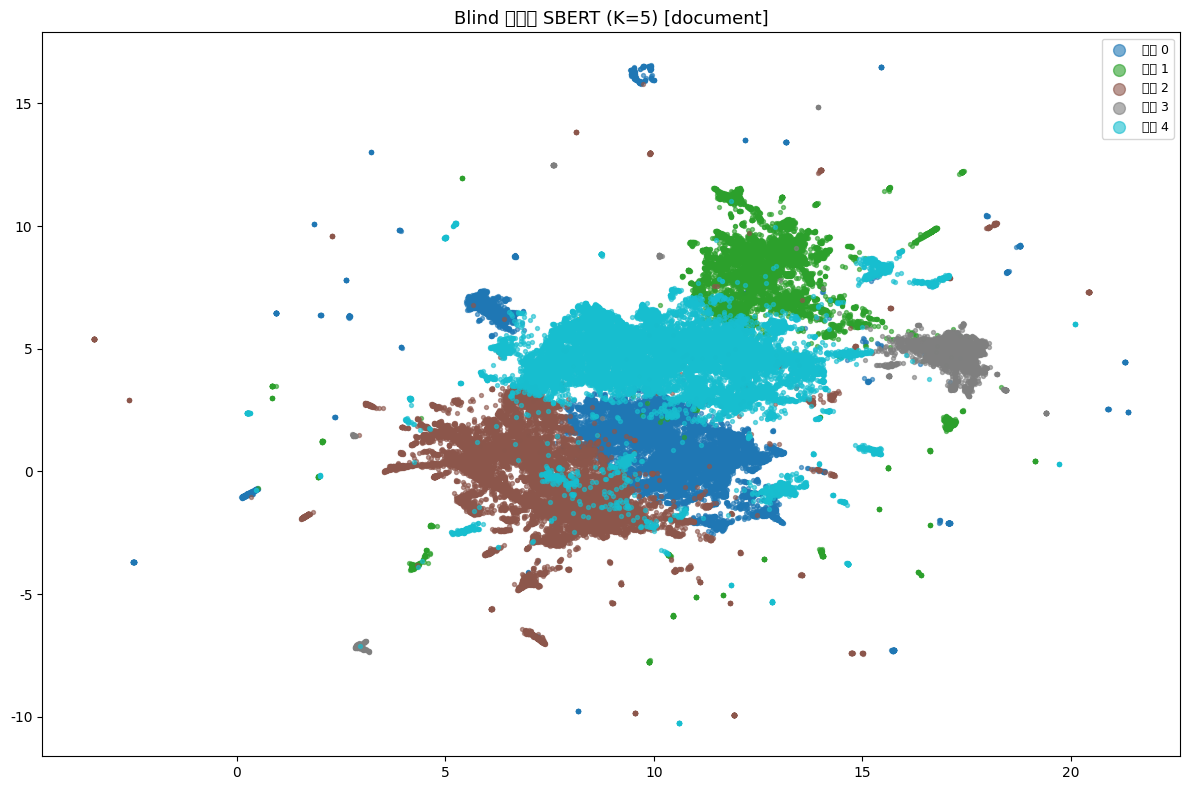

In [17]:
N_SBERT = 5   # 직접 수정 가능: N_SBERT = 7

km_sbert = KMeans(n_clusters=N_SBERT, random_state=42, n_init=10)
analysis_df["cluster_sbert"] = km_sbert.fit_predict(reduced_10d)
print(f"군집별 {'문장' if ANALYSIS_MODE == 'sentence' else '게시글'} 수 (SBERT):")
print(analysis_df["cluster_sbert"].value_counts().sort_index())

reducer_2d = umap.UMAP(n_components=2, metric="cosine", random_state=42)
xy_s = reducer_2d.fit_transform(embeddings)

cmap_s = plt.cm.get_cmap("tab10", N_SBERT)
plt.figure(figsize=(12, 8))
for c in range(N_SBERT):
    mask = analysis_df["cluster_sbert"] == c
    plt.scatter(xy_s[mask, 0], xy_s[mask, 1], s=8, alpha=0.6,
                color=cmap_s(c), label=f"군집 {c}")
plt.legend(markerscale=3, fontsize=9)
plt.title(f"Blind 번아웃 SBERT (K={N_SBERT}) [{ANALYSIS_MODE}]", fontsize=13)
plt.tight_layout(); plt.savefig(f"sbert_cluster_2d_{ANALYSIS_MODE}.png", dpi=150); plt.show()

### 3-4. 군집별 키워드(TF-IDF) & 대표 텍스트(코사인 유사도)

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_raw = TfidfVectorizer(max_features=5000)
tfidf_raw.fit(analysis_df[TEXT_COL])
feature_names_raw = tfidf_raw.get_feature_names_out()

unit = "문장" if ANALYSIS_MODE == "sentence" else "게시글"
print("=" * 70)
for c in range(N_SBERT):
    idx = analysis_df[analysis_df["cluster_sbert"] == c].index.tolist()
    cluster_embs = embeddings[idx]
    centroid = cluster_embs.mean(axis=0, keepdims=True)
    sims = cosine_similarity(centroid, cluster_embs)[0]
    top5 = [idx[i] for i in sims.argsort()[::-1][:5]]

    mat = tfidf_raw.transform(analysis_df.loc[idx, TEXT_COL].tolist())
    keywords = [feature_names_raw[i]
                for i in mat.mean(axis=0).A1.argsort()[::-1][:20]]

    print(f"\n【SBERT 군집 {c}】 ({len(idx)}{unit})")
    print(f"  키워드: {' | '.join(keywords)}")
    print(f"  대표 {unit}:")
    for rank, g in enumerate(top5, 1):
        preview = analysis_df.loc[g, TEXT_COL]
        print(f"    {rank}. {preview[:80]}{'...' if len(preview) > 80 else ''}")
print("=" * 70)


【SBERT 군집 0】 (13964게시글)
  키워드: 현관 | 공동현관 | 자유 | 청소 | 아파트 | 센서등 | 어떻게 | 관리사무소에 | 혹시 | 관리사무소 | 현관에 | 재생 | 1층 | 있습니다 | 너무 | 제가 | 입주민 | 합니다 | 인테리어 | 있는
  대표 게시글:
    1. 자유수다방센서등문제 인테리어다끝나고 입주청소점검하는데 현관센서겸 현관스위치등이 안켜지네요 이거무슨문제일까요 방법아시는분댓글 부탁드려요
    2. 독취사 자유게시판아파트시설관리 상시등 교체하는거 현관안에 센서등 교체하는거 한번보면 알아야하는데 모른다고.. 뭐라하시네요. 센서등이랑 비상센서등...
    3. 일상이야기통진근처 현관 방충망 연락처 알수있을까요? 저희아파트에 얼마전 광고지가 층층마다 붙어있었는데 청소하시는분이 다 치우셔서... 혹시 현관...
    4. 엄마들의 수다방아파트 현관 앞 물건 적재하는 관련 질문이예요. 신축아파트인데 계단이나 비상문을 막은 건 아닌데 옆집에서도보이는 위치에 키높은 가...
    5. 건의문의민원사항현관출입구 집에 잠시 들렀는데, 현관출입구 . 샘플로 작업 해놓은듯 싶습니다. 문안한듯 한데...회원님들은 어떠세요? 의견 주시면...

【SBERT 군집 1】 (9536게시글)
  키워드: 인테리어 | 아파트 | 리모델링 | 현관 | 시공 | 현관인테리어 | 부산 | 재생 | 화이트 | 주방 | 중문 | 시공하여 | 거실 | naver | 공간을 | 있는 | 셀프인테리어 | 현관중문 | 자막 | 안방
  대표 게시글:
    1. 업체가 쓴시공후기 카페와 무관판교인테리어 모던한 감성의 48평 아파트 리모델링 후기입니다. 안녕하세요. 판교인테리어 전문 캄디자인입니다. 오늘은...
    2. 후원마감게시글Design studio 집이야기 인테리어입니다 안녕하세요 의정부이야기 회원님들 오늘은 별내 동익미라벨 38평형 인테리어 현장 소개...
    3. 후원마감게시글Design studio 집이야기 인테리어입니다 안녕하세요 의정부이야

---
## 세 방법 나란히 비교 (UMAP 2D)

## 결과 저장

In [19]:
output_csv   = f"{RAW_CSV}_{ANALYSIS_MODE}.csv"
output_model = f"{RAW_CSV}_{ANALYSIS_MODE}.model"

analysis_df.to_csv(output_csv, index=False, encoding="utf-8-sig")
#d2v.save(output_model)

print("저장 완료 ✅")
print(f"  → {output_csv}")
print(f"  → {output_model}")
print(f"  → tfidf/d2v/sbert_cluster_2d_{ANALYSIS_MODE}.png")
print(f"  → {RAW_CSV}_{ANALYSIS_MODE}.png")
analysis_df.head()

저장 완료 ✅
  → /content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX프로젝트/marged_output/01_Entrance_merged.csv_document.csv
  → /content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX프로젝트/marged_output/01_Entrance_merged.csv_document.model
  → tfidf/d2v/sbert_cluster_2d_document.png
  → /content/drive/MyDrive/Colab Notebooks/LG전자DX스쿨/CX프로젝트/marged_output/01_Entrance_merged.csv_document.png


,doc_idx,text,tokens,tokens_str,cluster_sbert
0,0,자유수다방현관시트지색 오늘 타일을 보고왔는데 눈이 핑핑돌더라구요 계속보니 이색이 이...,"[자유, 다방, 현관, 시트지, 타일, 이색, 생각, 생각, 민트, 타일, 들어오,...",자유 다방 현관 시트지 타일 이색 생각 생각 민트 타일 들어오 현관 바닥 현관 신발...,4
1,1,인테리어 질문현관 디딤석 없는집? 안녕하세여 현관 인테리어 예정입니다 현관 디딤석이...,"[인테리어, 질문, 현관, 디디, 안녕, 현관, 인테리어, 예정, 현관, 디디, 시...",인테리어 질문 현관 디디 안녕 현관 인테리어 예정 현관 디디 시공 사진 디디 없애 ...,4
2,2,기타업종 구직홍보 게시판망원2동 누수탐지 주택 현관 천장 누수 망원2동 누수탐지 주...,"[기타, 업종, 구직, 홍보, 게시판, 망원, 누수, 탐지, 주택, 현관, 천장, ...",기타 업종 구직 홍보 게시판 망원 누수 탐지 주택 현관 천장 누수 망원 누수 탐지 ...,0
3,3,자유수다방현관쪽에 전신거울 신발장쪽 현관쪽에 벽걸이 전신거울 하려고 하는데 택배왔는...,"[자유, 다방, 현관, 전신, 거울, 신발장, 현관, 벽걸이, 전신, 거울, 택배,...",자유 다방 현관 전신 거울 신발장 현관 벽걸이 전신 거울 택배 생각 아크릴 재질 거...,4
4,4,"인테리어 질문현관 덧방, 디딤석 철거 고민됩니다 ! 23년 내 매도 예정이나, 아파...","[인테리어, 질문, 현관, 디디, 철거, 고민, 매도, 예정, 아파트, 순정, 상태...",인테리어 질문 현관 디디 철거 고민 매도 예정 아파트 순정 상태 한정 예산 셀프 준...,4
